In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.optim as optim

torch.set_printoptions(edgeitems=2, linewidth=75)

In [2]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1) # Returns a new tensor with a dimension of size one inserted at the specified position.
t_u = torch.tensor(t_u).unsqueeze(1) # 

print('t_u : ', t_u)

t_u.shape

t_u :  tensor([[35.7000],
        [55.9000],
        [58.2000],
        [81.9000],
        [56.3000],
        [48.9000],
        [33.9000],
        [21.8000],
        [48.4000],
        [60.4000],
        [68.4000]])


torch.Size([11, 1])

In [3]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)
print('n_val : ', n_val)

shuffled_indices = torch.randperm(n_samples)    # every run indices changes : so alwaus run from the start 

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

n_val :  2


(tensor([4, 6, 3, 7, 9, 0, 2, 8, 5]), tensor([10,  1]))

In [4]:
t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

print('t_u_val :', t_u_val)
print('t_c_val :', t_c_val)

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

t_u_val : tensor([[68.4000],
        [55.9000]])
t_c_val : tensor([[21.],
        [14.]])


In [5]:
import torch.nn as nn

linear_model = nn.Linear(1, 1) # <1> The arguments are input size, output size, and bias defaulting to True.
linear_model(t_un_val)

tensor([[-2.2393],
        [-2.0046]], grad_fn=<AddmmBackward0>)

In [6]:
linear_model.weight

Parameter containing:
tensor([[-0.1877]], requires_grad=True)

In [7]:
linear_model.bias

Parameter containing:
tensor([-0.9552], requires_grad=True)

In [8]:
x = torch.ones(1)
print('x :', x)

linear_model(x)

x : tensor([1.])


tensor([-1.1430], grad_fn=<AddBackward0>)

In [9]:
x = torch.ones(10, 1)
print('x :', x)
linear_model(x)

x : tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


tensor([[-1.1430],
        [-1.1430],
        [-1.1430],
        [-1.1430],
        [-1.1430],
        [-1.1430],
        [-1.1430],
        [-1.1430],
        [-1.1430],
        [-1.1430]], grad_fn=<AddmmBackward0>)

In [10]:
linear_model = nn.Linear(1, 1) # <1>
optimizer = optim.SGD(
    linear_model.parameters(), # <2>
    lr=1e-2)

In [11]:
linear_model.parameters()

<generator object Module.parameters at 0x000001A7F93A3900>

In [12]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[0.6968]], requires_grad=True),
 Parameter containing:
 tensor([-0.3290], requires_grad=True)]

In [13]:
def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,
                  t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train) # <1>
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val) # <1>
        loss_val = loss_fn(t_p_val, t_c_val)
        
        optimizer.zero_grad()
        loss_train.backward() # <2>
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")


In [14]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

linear_model = nn.Linear(1, 1) # <1>
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 3000, 
    optimizer = optimizer,
    model = linear_model,
    loss_fn = loss_fn,
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 79.9316, Validation loss 158.3570
Epoch 1000, Training loss 3.5874, Validation loss 5.5380
Epoch 2000, Training loss 2.9539, Validation loss 4.1055
Epoch 3000, Training loss 2.9416, Validation loss 3.9282

Parameter containing:
tensor([[5.2049]], requires_grad=True)
Parameter containing:
tensor([-16.8151], requires_grad=True)


In [15]:
seq_model = nn.Sequential(
            nn.Linear(1, 13), # <1>
            nn.Tanh(),
            nn.Linear(13, 1)) # <2>
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [16]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [17]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [18]:
from collections import OrderedDict

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 8)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(8, 1))
]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [19]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


In [20]:
seq_model.output_linear.bias

Parameter containing:
tensor([0.1531], requires_grad=True)

In [21]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3) # <1> Note that the learning rate has 
                                                       # dropped a bitto help with stability.

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)
    
print('output', seq_model(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 142.5322, Validation loss 287.5549
Epoch 1000, Training loss 6.5345, Validation loss 5.9446
Epoch 2000, Training loss 3.5690, Validation loss 10.2651
Epoch 3000, Training loss 1.7334, Validation loss 3.4019
Epoch 4000, Training loss 1.5718, Validation loss 3.5865
Epoch 5000, Training loss 1.5332, Validation loss 3.7474
output tensor([[20.2616],
        [11.3638]], grad_fn=<AddmmBackward0>)
answer tensor([[21.],
        [14.]])
hidden tensor([[-0.0022],
        [ 0.0346],
        [ 0.0008],
        [ 0.0044],
        [-0.0035],
        [-0.0033],
        [-0.0018],
        [-0.0028]])


In [22]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)
print('t_range :', t_range)



t_range : tensor([[20.],
        [21.],
        [22.],
        [23.],
        [24.],
        [25.],
        [26.],
        [27.],
        [28.],
        [29.],
        [30.],
        [31.],
        [32.],
        [33.],
        [34.],
        [35.],
        [36.],
        [37.],
        [38.],
        [39.],
        [40.],
        [41.],
        [42.],
        [43.],
        [44.],
        [45.],
        [46.],
        [47.],
        [48.],
        [49.],
        [50.],
        [51.],
        [52.],
        [53.],
        [54.],
        [55.],
        [56.],
        [57.],
        [58.],
        [59.],
        [60.],
        [61.],
        [62.],
        [63.],
        [64.],
        [65.],
        [66.],
        [67.],
        [68.],
        [69.],
        [70.],
        [71.],
        [72.],
        [73.],
        [74.],
        [75.],
        [76.],
        [77.],
        [78.],
        [79.],
        [80.],
        [81.],
        [82.],
        [83.],
        [84.],
        [85.],


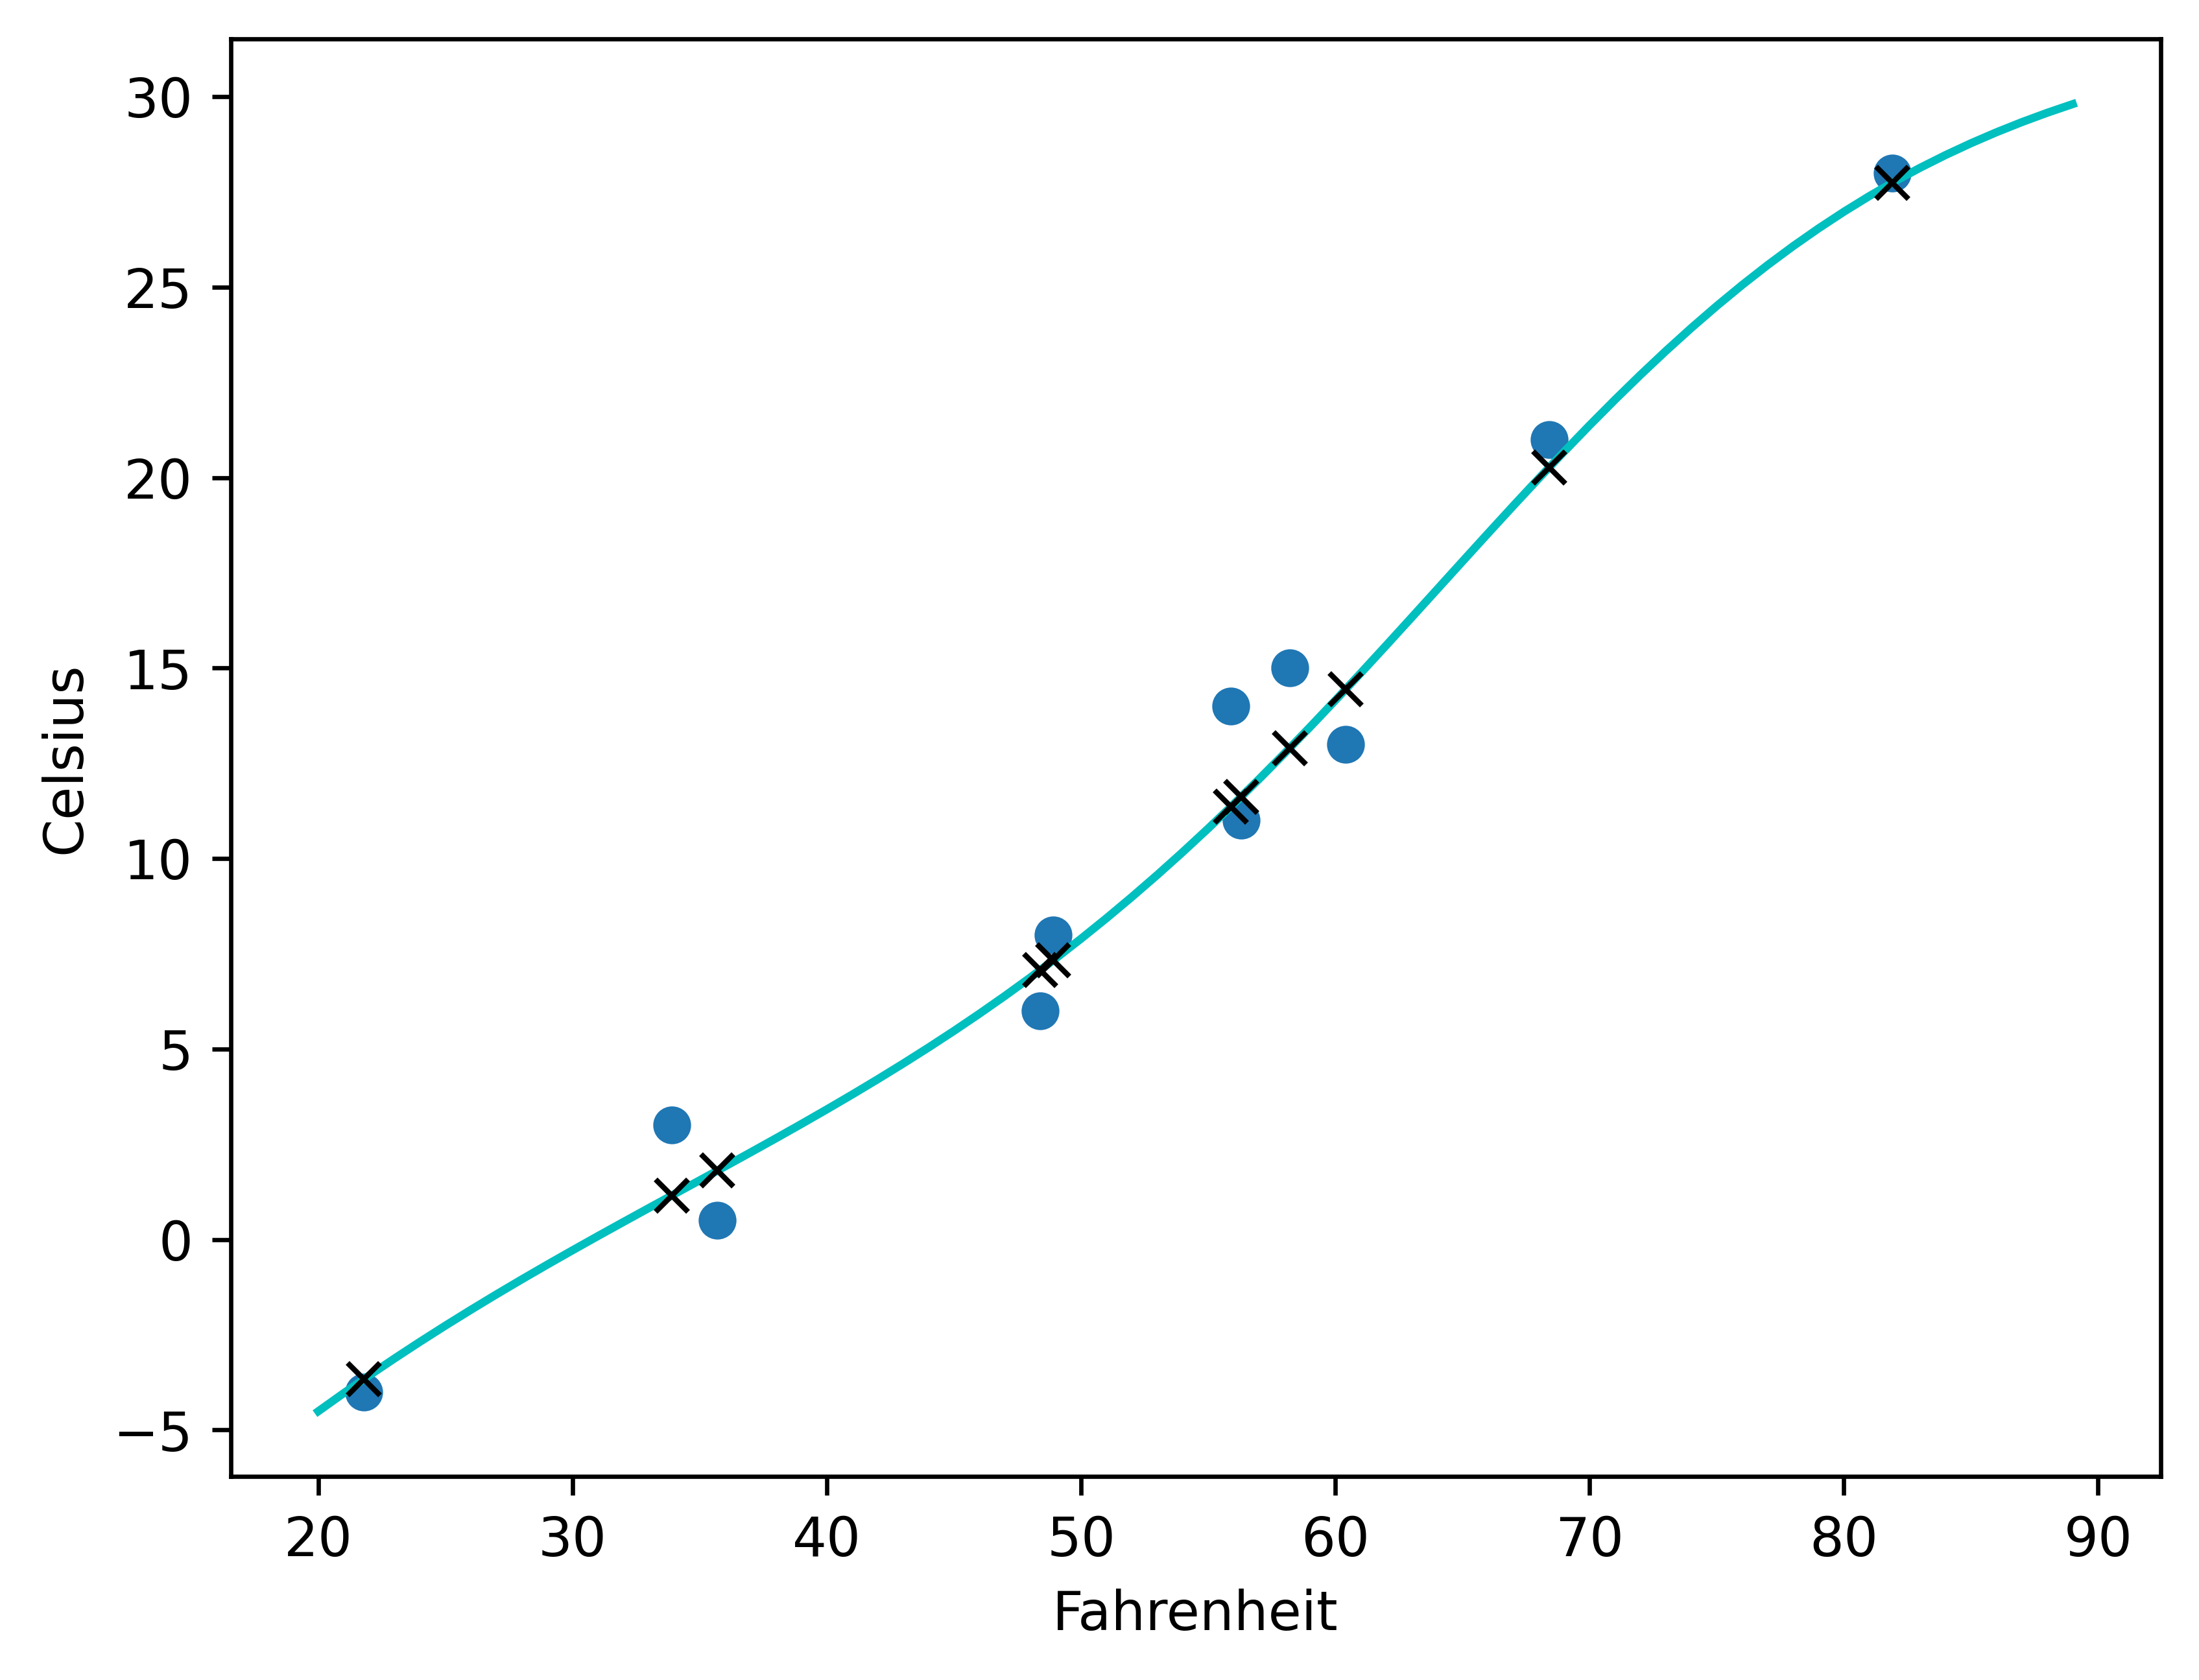

In [23]:
fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')         # color/line
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')                 # color/marker


Epoch 1, Training loss 163.9633, Validation loss 329.4271
Epoch 1000, Training loss 60.0443, Validation loss 70.9883
Epoch 2000, Training loss 43.0837, Validation loss 49.5755
Epoch 3000, Training loss 29.0606, Validation loss 33.7128
Epoch 4000, Training loss 18.3488, Validation loss 21.6375
Epoch 5000, Training loss 11.7685, Validation loss 13.6092


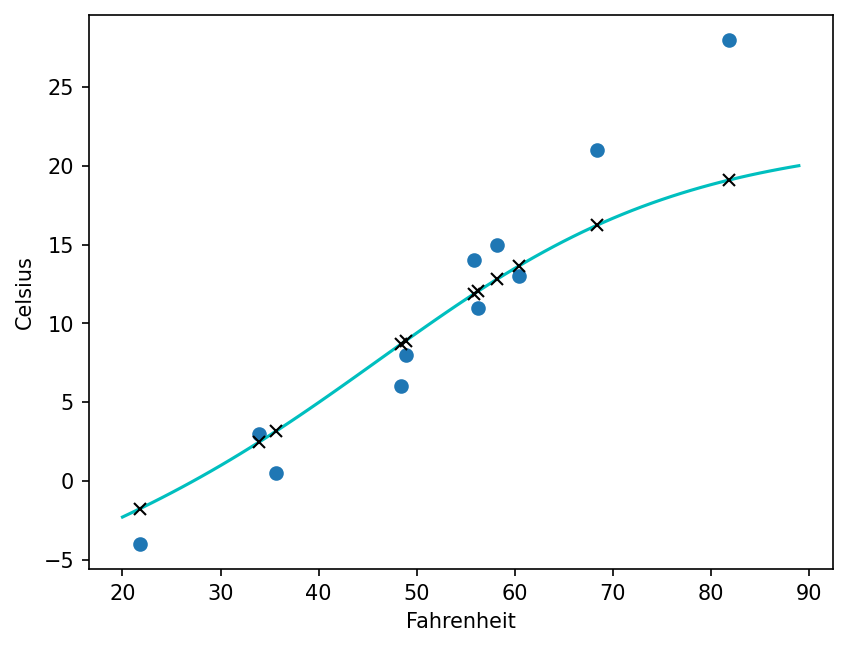

In [24]:
neuron_count = 20

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, neuron_count)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(neuron_count, 1))
]))

optimizer = optim.SGD(seq_model.parameters(), lr=1e-4)

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=150)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')